In [2]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torchvision
from torchvision.transforms import ToTensor
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader, Dataset
from torch.optim import Adam


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
# 데이터 다운로드 -> 데이터 적재(Loader)
# 다운로드
train_set = MNIST(root='./data', train=True, transform=ToTensor(), download=True)
test_set = MNIST(root='./data', train=False, transform=ToTensor(), download=True)


train_loader = DataLoader(train_set, batch_size=128, shuffle=True)  # 메모리로 보내 CPU로 보낼 수 있음.
test_loader = DataLoader(test_set, batch_size=128, shuffle=False)


Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:02<00:00, 4.48MB/s]


Extracting ./data\MNIST\raw\train-images-idx3-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 153kB/s]


Extracting ./data\MNIST\raw\train-labels-idx1-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1.65M/1.65M [00:01<00:00, 1.44MB/s]


Extracting ./data\MNIST\raw\t10k-images-idx3-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<00:00, 2.27MB/s]

Extracting ./data\MNIST\raw\t10k-labels-idx1-ubyte.gz to ./data\MNIST\raw



In [4]:
# 강제로 노이즈 추가함수
def add_noise(imgs, noise_factor=0.5):
    noisy_imgs = imgs + noise_factor * torch.randn_like(imgs)
    noisy_imgs = torch.clip(noisy_imgs, 0., 1.)
    return noisy_imgs


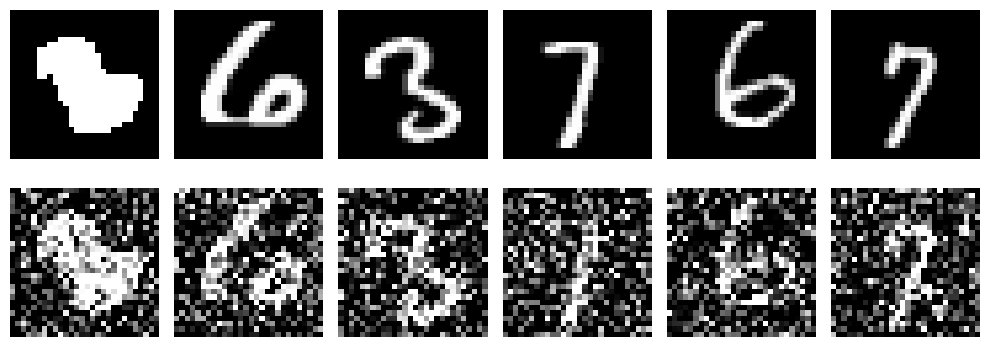

In [ ]:
x, _ = next(iter(train_loader)) # iterable로 바꾸면 next가 가능. 다음 거.
noisy_x = add_noise(x)
plt.figure(figsize=(10, 4))
for i in range(6):  # 이미지 6개 추출
    # 원본 이미지
    plt.subplot(2, 6, i + 1)
    plt.imshow(x[i][0], cmap='gray')
    plt.axis('off')
    # 노이즈 이미지
    plt.subplot(2, 6, i + 7)
    plt.imshow(noisy_x[i][0], cmap='gray')
    plt.axis('off')
plt.tight_layout()
plt.show()


In [10]:
# 오토인코더 모델 구성
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        # Encoder: 784 → 128 → 64 → 32
        self.encoder = nn.Sequential(
        nn.Linear(28*28, 128), nn.ReLU(),
        nn.Linear(128, 64), nn.ReLU(),
        nn.Linear(64, 32)) #, nn.ReLU() )  # 여기 relu 들어가면 안 됨. 압축된 데이터는 음수도 의미가 있는데 relu로 음수가 다 0이 됨. decoder할 때 손실된 상태로 넘어감.
        # Decoder: 32 → 64 → 128 → 784
        self.decoder = nn.Sequential(
        nn.Linear(32, 64), nn.ReLU(),
        nn.Linear(64, 128), nn.ReLU(),
        nn.Linear(128, 28*28),
        nn.Sigmoid() ) # 픽셀 범위를 [0,1]로 맞추기 위해 시그모이드 함수 사용. 데이터도 0~255를 /255해줘서 0~1사이로 바꿔줌.
    def forward(self, x):
        x = x.view(x.size(0), -1)
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded.view(x.size(0), 1, 28, 28)
                            # 28      #흑백 


In [11]:
model = Autoencoder().to(device)
loss_fn = nn.MSELoss()      # MSE 써도 문제는 없음. sigmoid(0~1사이 값)라고 무조건 분류를 위함이 아님. 0~1을 비교하여 오차 구하기 위함.
# BCE 를 주는 것도 괜찮. BCE를 주는 게 성능상 더 나음.
# (MSE는 소수를 제곱해야 함. 오차가 더 작아짐. lr과 충돌할 수 있음. 순수값의 오차를 구하는 게 더 나음.)
optimizer = Adam(model.parameters(), lr=0.001)


In [ ]:
# 학습
# 일반적인 오토인코드 모델들은 입력=정답
epochs = 20
for t in range(epochs):
    model.train()
    running_loss = 0.0
    for imgs, _ in train_loader:
        # 아래 코드 문제점 파악
        # nvidia rtx
        # core 4가지 종류. : 연산
        #  - cuda core : 일반 연산(사칙)
        #  - tensor core : 행렬 연산(RTX에만 tensor core 있음.). tesnor core 많을 수록 행렬 연산 빠름. 텐서 코어 개수 확인해봐야.
        #  - RT core: 빛반사/그림자 등... 우리는 쓸모 없음..
        #  - SFU: 삼각함수, 로그, 제곱 등 특수함수 연산
        imgs = imgs.to(device)
        noisy_imgs = add_noise(imgs)                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              # cpu에서 이미지 변환한 후 gpu로 넘김. 
        # gpu에 보낸 후 noise 키우는 게 더 빠름.
        # imgs = imgs.to(device)
        outputs = model(noisy_imgs)
        loss = loss_fn(outputs, imgs)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    tr_loss = running_loss / len(train_loader)
    print(f"Epoch {t+1}, train loss: {tr_loss:.6f}")
    
# encoder의 ReLU 있을 때: Epoch 20, train loss: 0.020619
# encoder의 ReLU 없을 때: Epoch 20, train loss: 0.019728

# val loss 도 꼭 필요. 과적합 확인 위해

Epoch 1, train loss: 0.068693
Epoch 2, train loss: 0.044269
Epoch 3, train loss: 0.034456
Epoch 4, train loss: 0.030947
Epoch 5, train loss: 0.028908
Epoch 6, train loss: 0.027469
Epoch 7, train loss: 0.026407
Epoch 8, train loss: 0.025336
Epoch 9, train loss: 0.024409
Epoch 10, train loss: 0.023611
Epoch 11, train loss: 0.022980
Epoch 12, train loss: 0.022441
Epoch 13, train loss: 0.022032
Epoch 14, train loss: 0.021638
Epoch 15, train loss: 0.021286
Epoch 16, train loss: 0.020939
Epoch 17, train loss: 0.020568
Epoch 18, train loss: 0.020239
Epoch 19, train loss: 0.019968
Epoch 20, train loss: 0.019728


In [ ]:
model.eval()
imgs, _ = next(iter(test_loader))
noisy_imgs = add_noise(imgs).to(device)
with torch.no_grad():
    # model 학습이 된 상태.
    outputs = model(noisy_imgs)


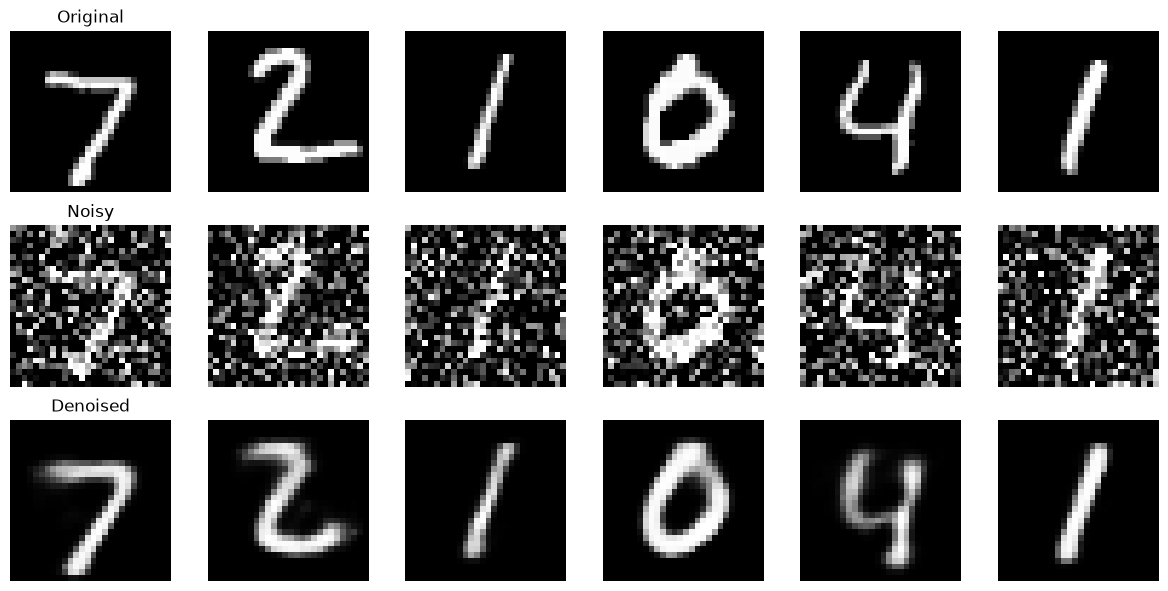

In [ ]:
imgs = imgs[:6].cpu()
noisy_imgs = noisy_imgs[:6].cpu()
outputs = outputs[:6].cpu()
plt.figure(figsize=(12, 6))
for i in range(6):
    # 원본      행 열  인덱스
    plt.subplot(3, 6, i + 1)    # subplots는 18개 다 만들라는 뜻.
    plt.imshow(imgs[i][0], cmap='gray')
    plt.axis('off')
    if i == 0: plt.title("Original")
    # 노이즈
    plt.subplot(3, 6, i + 7)
    plt.imshow(noisy_imgs[i][0], cmap='gray')
    plt.axis('off')
    if i == 0: plt.title("Noisy")
    # 복원
    plt.subplot(3, 6, i + 13)
    plt.imshow(outputs[i][0], cmap='gray')
    plt.axis('off')
    if i == 0: plt.title("Denoised")


plt.tight_layout()
plt.show()


In [16]:
class Autoencoder2D(nn.Module):
    def __init__(self):
        super(Autoencoder2D, self).__init__()
        self.encoder = nn.Sequential(
                        nn.Linear(784, 128), nn.ReLU(),
                        nn.Linear(128, 64), nn.ReLU(),
                        nn.Linear(64, 2))
        self.decoder = nn.Sequential(
                        nn.Linear(2, 64), nn.ReLU(),
                        nn.Linear(64, 128), nn.ReLU(),
                        nn.Linear(128, 784),
                        nn.Sigmoid())
    def forward(self, x):
        x = x.view(x.size(0), -1)
        z = self.encoder(x)
        out = self.decoder(z)
        return out.view(x.size(0), 1, 28, 28)
    def encode(self, x):
        x = x.view(x.size(0), -1)
        return self.encoder(x)


In [17]:
model = Autoencoder2D().to(device)
loss_fn = nn.MSELoss()
optimizer = Adam(model.parameters(), lr=0.001)


epochs = 20
for t in range(epochs):
    model.train() # 학습 모드
    running_loss = 0.0
    for imgs, _ in train_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        loss = loss_fn(outputs, imgs)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    tr_loss = running_loss / len(train_loader)
    print(f"Epoch {t+1}, train loss: {tr_loss:.6f}")


Epoch 1, train loss: 0.063678
Epoch 2, train loss: 0.050418
Epoch 3, train loss: 0.047082
Epoch 4, train loss: 0.045138
Epoch 5, train loss: 0.044104
Epoch 6, train loss: 0.043339
Epoch 7, train loss: 0.042636
Epoch 8, train loss: 0.042060
Epoch 9, train loss: 0.041508
Epoch 10, train loss: 0.040997
Epoch 11, train loss: 0.040647
Epoch 12, train loss: 0.040273
Epoch 13, train loss: 0.039945
Epoch 14, train loss: 0.039654
Epoch 15, train loss: 0.039441
Epoch 16, train loss: 0.039190
Epoch 17, train loss: 0.038997
Epoch 18, train loss: 0.038821
Epoch 19, train loss: 0.038609
Epoch 20, train loss: 0.038481


In [ ]:
model.eval()
latent_vectors = []
labels = []
with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs = imgs.to(device)
        z = model.encode(imgs)  # (128,2)
        latent_vectors.append(z.cpu())
        labels.append(lbls)
latent_vectors = torch.cat(latent_vectors)
labels = torch.cat(labels)


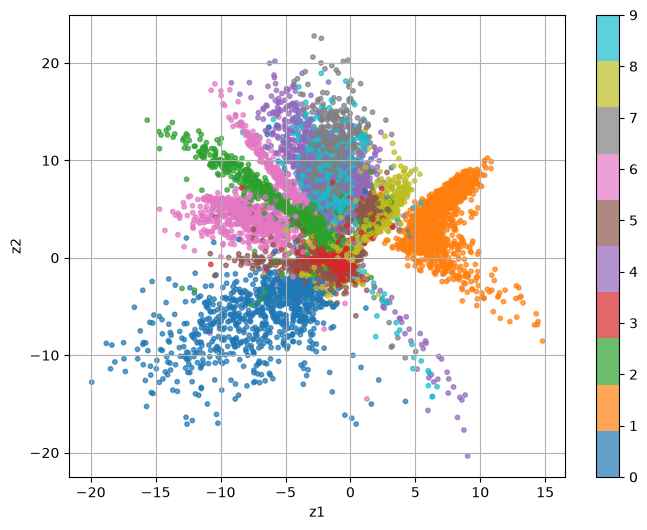

In [19]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(latent_vectors[:, 0], latent_vectors[:, 1], c=labels, cmap='tab10', s=10, alpha=0.7)
plt.colorbar(scatter, ticks=range(10))
plt.xlabel("z1")
plt.ylabel("z2")
plt.grid()
plt.show()
